#Tasks


=== Classification Quality Assessment ===
Calculated AUC Score: 0.9954


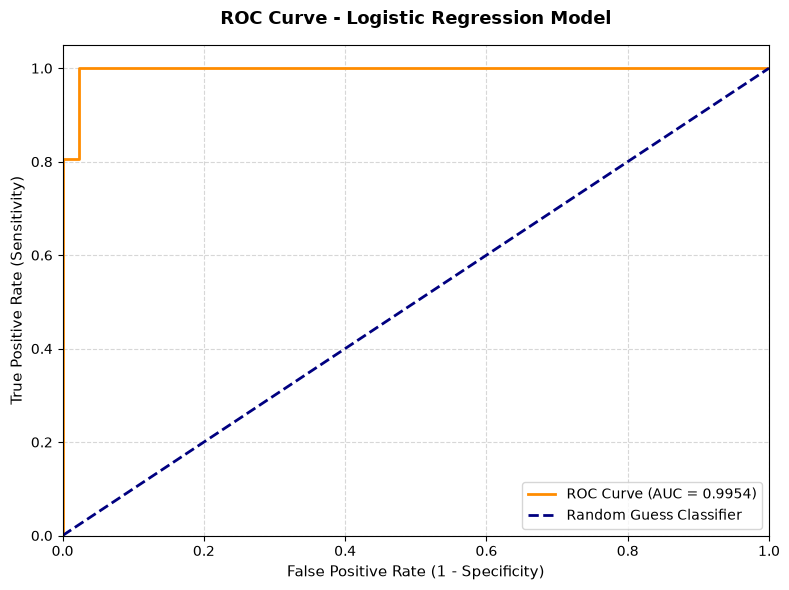

In [1]:
#task-1
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import auc, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Load the Breast Cancer Dataset
cancer = load_breast_cancer()
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = cancer.target  # 0 = Malignant, 1 = Benign

# 2. Split Data (80/20 Partition) with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 3. Standardize Features
# Logistic Regression handles coefficients better when features are scaled
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Initialize and Train Logistic Regression Model
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

# 5. Extract Predicted Probabilities for the Positive Class (Benign = 1)
# [:, 1] extracts the probability of the sample being positive
y_probs = log_reg.predict_proba(X_test_scaled)[:, 1]

# 6. Calculate ROC Curve parameters and AUC Score
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

print("=== Classification Quality Assessment ===")
print(f"Calculated AUC Score: {roc_auc:.4f}")

# 7. Plot the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess Classifier')

# Formatting the Chart canvas
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title('ROC Curve - Logistic Regression Model', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.show()


In [5]:
#task-2
# Import libraries
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load dataset
iris = load_iris()

X = iris.data
y = iris.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create Random Forest model
rf = RandomForestClassifier(random_state=42)

# Hyperparameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# GridSearchCV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Train Grid Search
grid_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:")
print(grid_search.best_params_)

# Best cross-validation accuracy
print("\nBest CV Accuracy:")
print(grid_search.best_score_)

# Best model
best_rf = grid_search.best_estimator_

# Predict on test data
y_pred = best_rf.predict(X_test)

# Test Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("\nTest Accuracy:", accuracy)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}

Best CV Accuracy:
0.9583333333333334

Test Accuracy: 1.0


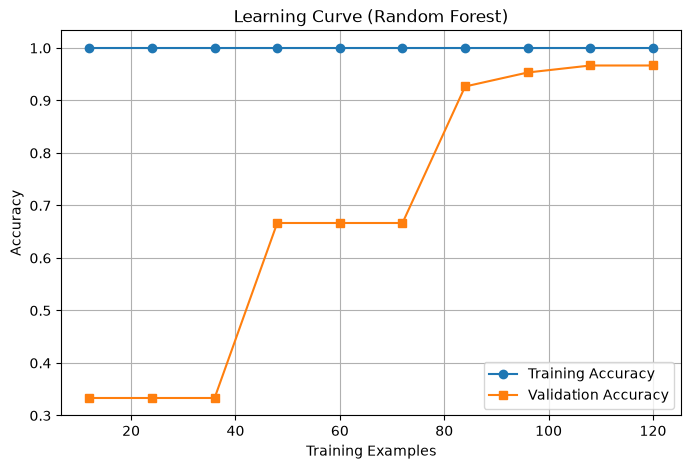

In [6]:
#task-3
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Model
model = RandomForestClassifier(random_state=42)

# Compute learning curve
train_sizes, train_scores, test_scores = learning_curve(
    model,
    X,
    y,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

# Mean scores
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

# Plot
plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, marker='o', label='Training Accuracy')
plt.plot(train_sizes, test_mean, marker='s', label='Validation Accuracy')

plt.xlabel("Training Examples")
plt.ylabel("Accuracy")
plt.title("Learning Curve (Random Forest)")
plt.legend()
plt.grid(True)

plt.show()

In [7]:
#task-4
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

# Store results
results = []

# Train and evaluate
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted"),
        "Recall": recall_score(y_test, y_pred, average="weighted"),
        "F1-Score": f1_score(y_test, y_pred, average="weighted")
    })

# Create DataFrame
comparison_df = pd.DataFrame(results)

# Display results
print(comparison_df)

                 Model  Accuracy  Precision  Recall  F1-Score
0  Logistic Regression       1.0        1.0     1.0       1.0
1        Decision Tree       1.0        1.0     1.0       1.0
2        Random Forest       1.0        1.0     1.0       1.0


#Practice Sheet

In [8]:
#Practice sheet-1
# Import libraries
import pandas as pd

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# -------------------------------------------------
# 1. Load Dataset
# -------------------------------------------------
iris = load_iris()
X = iris.data
y = iris.target

# -------------------------------------------------
# 2. Train-Test Split
# -------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -------------------------------------------------
# 3. Define Models
# -------------------------------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Support Vector Machine": SVC()
}

# -------------------------------------------------
# 4. Train & Evaluate
# -------------------------------------------------
results = []

for name, model in models.items():

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    # Store
    results.append({
        "Model": name,
        "Accuracy": round(accuracy,4),
        "Precision": round(precision,4),
        "Recall": round(recall,4),
        "F1-Score": round(f1,4)
    })

# -------------------------------------------------
# 5. Create Comparison Table
# -------------------------------------------------
comparison = pd.DataFrame(results)

# Rank by F1-Score
comparison = comparison.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

comparison["Rank"] = comparison.index + 1

# Rearrange columns
comparison = comparison[
    ["Rank","Model","Accuracy","Precision","Recall","F1-Score"]
]

print(comparison)

   Rank                   Model  Accuracy  Precision  Recall  F1-Score
0     1     K-Nearest Neighbors    1.0000     1.0000  1.0000    1.0000
1     2     Logistic Regression    0.9667     0.9697  0.9667    0.9666
2     3  Support Vector Machine    0.9667     0.9697  0.9667    0.9666
3     4           Decision Tree    0.9333     0.9333  0.9333    0.9333
4     5           Random Forest    0.9000     0.9024  0.9000    0.8997


In [9]:
#Practice sheet-2
# Import libraries
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create SVM model
svm = SVC()

# Hyperparameter Grid
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto', 0.1, 0.01]
}

# Grid Search
grid_search = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Train Grid Search
grid_search.fit(X_train, y_train)

# Best Parameters
print("Best Parameters:")
print(grid_search.best_params_)

# Best Cross-Validation Score
print("\nBest CV Accuracy:")
print(grid_search.best_score_)

# Best Model
best_svm = grid_search.best_estimator_

# Predictions
y_pred = best_svm.predict(X_test)

# Test Accuracy
print("\nTest Accuracy:")
print(accuracy_score(y_test, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Best Parameters:
{'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}

Best CV Accuracy:
0.9833333333333334

Test Accuracy:
0.9666666666666667

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

